# Analyse Time in EuXFEL switchyard

In [12]:
import os
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-backgrounds/06_analysis/')

import numpy as _np
import matplotlib.pyplot as _plt
import pickle as _pk
import pymad8 as _m8

import matplotlib.ticker as mtick
import matplotlib.patches as _patch
from pdf2image import convert_from_path

import XFEL_BPM
import loadXFELdata
import plotXFELdata

### Date and save prefix

In [2]:
date = "2026_07_07"
save_name_prefix = "jupyter_notebooks/plots/EUXFEL/Energy/" + date + "_EuXFEL_plot"

### Load file

In [3]:
file = 'XFEL_data/ArrivalTime_data/matched_linac_main_run2148_file109482_20231119T155947.all.hdf5'
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file114155_20231120T155943.all.hdf5'

In [4]:
BPMData = loadXFELdata.XFELdata(file, getPosition=False, getCharge=False, getEnergy=True, getTime=False)

Loaded file 'matched_linac_main_run2148_file114155_20231120T155943.all.hdf5'
Loading 49 bpms, 3391 trains and 2708 bunches in df: |██████████████████████████████████████████████████| 100.0% Complete


## Plot

In [5]:
def plotOneHist(ax, df_reduced, coord='X', label="x", unit=r"$\rm \mu m$", minCut=None, maxCut=None, nbins=50):
    X_cut = df_reduced[coord][minCut:maxCut]
    ax.hist(X_cut, bins=nbins, histtype='step', color='C0',
            label=r"$\sigma_{{s,{}}}$ = {:.2f} {}".format(label, _np.std(X_cut* 1e3), 'MeV'))
    ax.set_ylabel("counts")
    ax.set_xlabel(r"${}$ [{}]".format(label, unit))
    ax.legend()
    ax.set_ylim([0, 240])
    
def addDrawing(axes=[0, 0.9, 1, 0.23]):
    img = convert_from_path("../../../Drawings/XS1_diag_XTLD.pdf", dpi=300)[0]
    arrow_xy=[235, 172, 30, 135]
    ax_pdf = _plt.gcf().add_axes(axes)
    ax_pdf.imshow(img)
    ax_pdf.axis('off')
    arrow = _patch.Rectangle((arrow_xy[0], arrow_xy[1]), arrow_xy[2], arrow_xy[3], lw=1.8, fill=False, color='r')
    ax_pdf.add_patch(arrow)
    ax_pdf.text(arrow_xy[0]+arrow_xy[2]/2, arrow_xy[1]-9, 'EBPM', color='r', ha='center', va='bottom', fontsize=9)

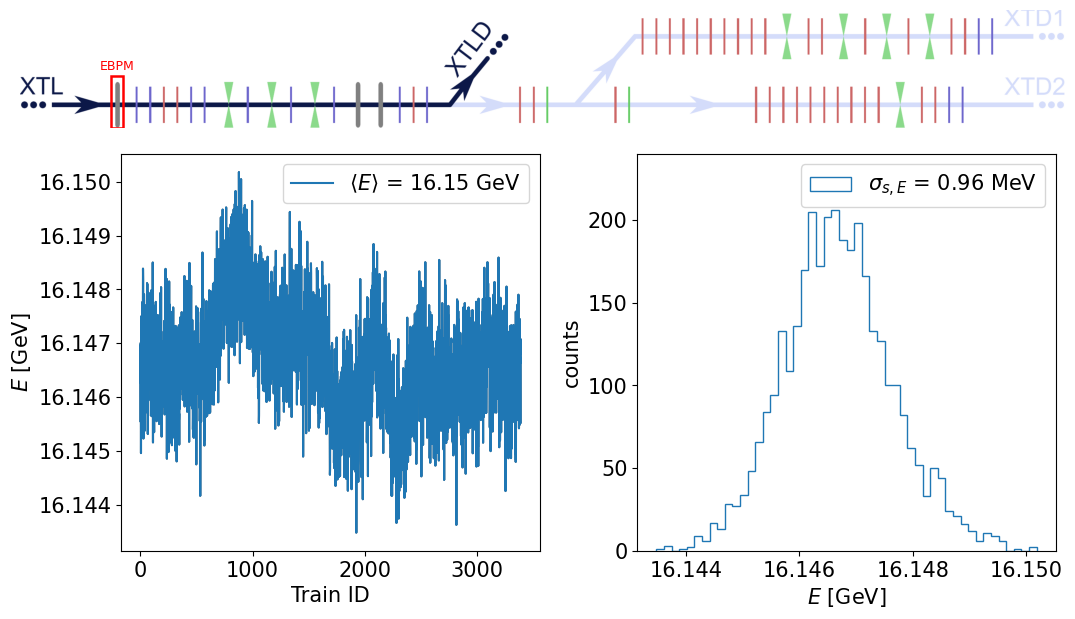

In [6]:
minCut=None
maxCut=None
df_reduced = BPMData.reduceDFbyBPMTrainBunchByIndex(bpms="BPMA.1873.TL", trains=None, bunches=91)
xlabel = 'Train ID'
slist = df_reduced.index.get_level_values('TrainID')
slist -= slist[0]

fig = _plt.figure(figsize=[11, 5])
gs = fig.add_gridspec(1, 2)
ax_left = fig.add_subplot(gs[0, 0])
ax_left.yaxis.set_major_formatter(mtick.ScalarFormatter(useOffset=False))
ax_right = fig.add_subplot(gs[0, 1])
ax_right.xaxis.set_major_formatter(mtick.ScalarFormatter(useOffset=False))

plotXFELdata.plotOneAlong(ax_left, df_reduced, slist, xlabel, coord='E', label="E", unit='GeV', minCut=minCut, maxCut=maxCut)
plotOneHist(ax_right, df_reduced, coord='E', label="E", unit='GeV', minCut=minCut, maxCut=maxCut)
addDrawing(axes=[0.03, 1, 0.95, 0.25])
_plt.tight_layout()
_plt.savefig("{}_Energy_per_train.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

In [46]:
E0 = 16100 #MeV
Dx = 0.4 #m
x = 20e-6 #m
err_x = 10e-6 #m

_np.sqrt((Dx-x)/Dx**2) * err_x

np.float64(1.5811388300841898e-05)

In [9]:
file1 = "XFEL_data/Energy_data/EnergyPerBunch_data/mp2234914117-CL.pkl"
file2 = "XFEL_data/Energy_data/EnergyPerBunch_data/mp2234914147-CL.pkl"
file3 = "XFEL_data/Energy_data/EnergyPerBunch_data/mp2234914117-TLD.pkl"
file4 = "XFEL_data/Energy_data/EnergyPerBunch_data/mp2234914147-TLD.pkl"

In [88]:
def CutData(data, minCut=0, maxCut=None):
    bunchIDs = _np.arange(0, data.shape[0]*2, 2)
    return bunchIDs[minCut:maxCut], data[minCut:maxCut]

def plotEnergyPerBunch(data, minCut=450, maxCut=510, color='C0', label=True):
    b, E = CutData(data, minCut=minCut, maxCut=maxCut)
    if label:
        _plt.plot(b, E[:, 1], color=color, label=r"$\langle E \rangle$ = {:.3f} GeV".format(_np.mean(E[:400][:, 1])))
    else:
        _plt.plot(b, E[:, 1], color=color)

def plotEnergyHist(data, minCut=450, maxCut=510, color='C0'):
    b, E = CutData(data, minCut=minCut, maxCut=maxCut)
    _plt.hist(E[:, 1], bins=20, histtype='step', color=color, label=r"$\sigma_E$ = {:.3f} MeV".format(_np.std(E[:400][:, 1])*1e3))

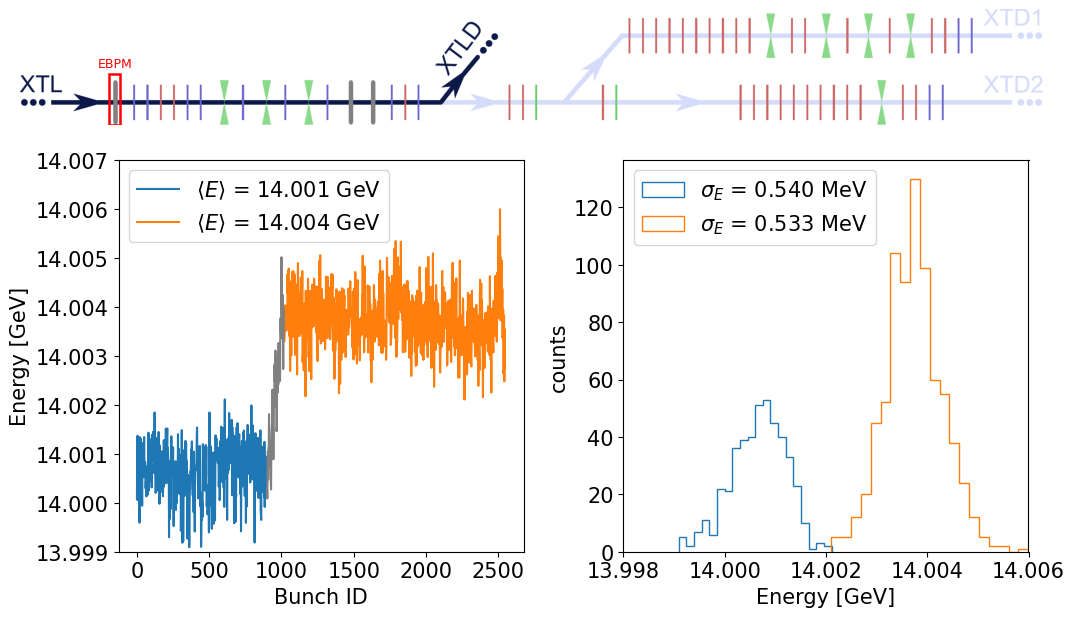

In [90]:
file = open(file1, 'rb')
energy_dict = _pk.load(file)
mask = (_np.nan_to_num(energy_dict['data']) != 0)
data = energy_dict['data'][mask[:, 1]]
data[:, 1] = data[:, 1]*1e-3
minCut=450
maxCut=510
_plt.subplots(1, 2, figsize=[11, 5])
_plt.subplot(121)
_plt.gca().yaxis.set_major_formatter(mtick.ScalarFormatter(useOffset=False))
plotEnergyPerBunch(data, 0, minCut, color='C0')
plotEnergyPerBunch(data, maxCut, None, color='C1')
plotEnergyPerBunch(data, minCut, maxCut, color='grey', label=False)
_plt.ylabel("Energy [GeV]")
_plt.xlabel("Bunch ID")
_plt.ylim([13.999, 14.007])
_plt.legend()
_plt.subplot(122)
_plt.gca().xaxis.set_major_formatter(mtick.ScalarFormatter(useOffset=False))
plotEnergyHist(data, 0, minCut, color='C0')
plotEnergyHist(data, maxCut, None, color='C1')
_plt.ylabel("counts")
_plt.xlabel("Energy [GeV]")
_plt.xlim([13.998, 14.006])
_plt.legend()
addDrawing(axes=[0.03, 1, 0.93, 0.25])
_plt.tight_layout()
_plt.savefig("{}_Energy_per_bunch.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

In [ ]:
def RemoveNan(self):
    mask = (_np.nan_to_num(self.energy_dict['data']) != 0)
    return self.energy_dict['data'][mask[:, 1]]



def PlotEnergyPerBunch(self, minBunch=0, maxBunch=None, color=None , label=True):
    
    if label:
        
    else:
        _plt.plot(E[:, 0], E[:, 1], color=color)

def PlotEnergyHist(self, minBunch=0, maxBunch=None, color=None):
    E = self.CutData(minBunch=minBunch, maxBunch=maxBunch)
    _plt.hist(E[:, 1], bins=20, color=color, label="$\sigma_E$ = {:.2e}".format(_np.std(E[:400][:, 1])))

def PlotAll(self, minCut=None, maxCut=None, figsize=[12, 5]):
    if minCut is None or maxCut is None:
        raise ValueError("Must provide cuts for plotting")
    fig, ax = plotOptions(figsize=figsize, rows_colums=[1, 2], height_ratios=None, sharex=False, sharey=False, font_size=15)
    ax[0].yaxis.set_major_formatter(mtick.ScalarFormatter(useOffset=False))
    ax[1].yaxis.set_major_formatter(mtick.ScalarFormatter(useOffset=False))
    ax[0].xaxis.set_major_formatter(mtick.ScalarFormatter(useOffset=False))
    ax[1].xaxis.set_major_formatter(mtick.ScalarFormatter(useOffset=False))
    ax[1].xaxis.set_major_locator(mtick.MaxNLocator(nbins=5))

    _plt.subplot(1, 2, 1)
    self.PlotEnergyPerBunch(0, minCut, color='C0')
    self.PlotEnergyPerBunch(maxCut, None, color='C1')
    self.PlotEnergyPerBunch(minCut, maxCut, color='grey', label=False)
    _plt.ticklabel_format(axis="both", style="sci", scilimits=(-3, 3))
    #_plt.xticks(rotation=45)
    _plt.ylabel("Energy [MeV]")
    _plt.xlabel("Bunch time [ns]")
    _plt.legend()

    _plt.subplot(1, 2, 2)
    self.PlotEnergyHist(0, minCut, color='C0')
    self.PlotEnergyHist(maxCut, None, color='C1')
    _plt.ticklabel_format(axis="both", style="sci", scilimits=(-3, 3))
    #_plt.xticks(rotation=45)
    _plt.xlabel("Energy [MeV]")
    _plt.legend()